# 03 · FunnyBirds MCBM — does minimality make concepts follow their parts?

Notebook 02 found a part-specific swap-following failure in a standard CBM. MCBM is a natural
next model because its extra penalty tries to remove information from each concept latent that
is not needed for that concept.

We do **not** assume it succeeds or fails. The order is:
1. verify that changing γ actually changed the representation;
2. learn what range of γ was truly tested;
3. repeat the same swap test used for CBM;
4. check visibility and seed uncertainty;
5. inspect deletion, species information, and downstream effect as supporting evidence.

`γ=0` MCBM is not the standard CBM: the architecture and scale differ. CBM remains a separate
reference rather than being treated as the first point on the γ line.


In [1]:
import os, json, re, glob
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
CURATED = Path(os.environ["CURATED_DATA"]); REPO = Path.cwd().parent
import sys; sys.path.insert(0, str(REPO/"analysis"))
try:
    from plotting import set_paper_style, PALETTE; set_paper_style()
    CBM_C, MCBM_C = PALETTE["CBM"], PALETTE["MCBM"]
except Exception:
    CBM_C, MCBM_C = "#0072B2", "#D55E00"
plt.rcParams["figure.dpi"]=120
EPS = 1e-3
def parse_stem(stem):
    m=re.match(r"^funnybirds-(vanilla|cbm|mcbm)(?:-g([0-9p]+))?-s(\d+)$", stem)
    if not m: return None
    gamma=float(m.group(2).replace("p",".")) if m.group(2) else np.nan
    return m.group(1), gamma, int(m.group(3))
def need(p, how):
    ok=Path(p).exists()
    if not ok: print(f"[pending] {p}\n  produce it:  {how}")
    return ok
# ---- seed-aware grounding loaders ----
def load_grounding(prefix):
    """All seeds for a config prefix -> one df with a 'seed' column (None if absent)."""
    fs = sorted(glob.glob(str(CURATED/"grounding"/f"{prefix}-s*.parquet")))
    if not fs: return None
    out=[]
    for f in fs:
        d=pd.read_parquet(f); d["seed"]=int(re.search(r"-s(\d+)\.parquet$", f).group(1)); out.append(d)
    return pd.concat(out, ignore_index=True)
def per_part_seedagg(df, visible_only=True):
    """per (seed,part) retained_frac -> per-part mean/std/count across seeds."""
    d = df[df["changed_frac"]>EPS] if (visible_only and "changed_frac" in df.columns) else df
    g = d.groupby(["seed","part"]).agg(pi=("p_intact","mean"), pr=("p_removed","mean"))
    g["rf"] = g.pr/g.pi
    return g["rf"].groupby("part").agg(["mean","std","count"])


## 1 · Did γ actually change the representation?

A flat grounding result means nothing if the penalty never affected the model. Measure the
penalty target error, the scale of `z`, task accuracy, and concept accuracy at every setting.


In [ ]:
import torch
def zstats_seed(cfg, seed):
    pth = REPO/"external"/"minimal_cbm"/"results"/cfg/str(seed)/"predictions"/"epoch_100.pth"
    if not pth.exists(): return None
    d=torch.load(pth, map_location="cpu", weights_only=False); z,cc=d["z"].float(),d["c"].float()
    if not (np.isfinite(z).all() and np.isfinite(cc).all()): return None
    yp=d["y_preds"]; ta=float((yp.argmax(-1)==d["y"]).float().mean()) if yp.ndim>1 else float((yp==d["y"]).float().mean())
    cp=d["c_preds"]; cp=cp[...,0] if cp.ndim==3 else cp
    return float(((6*cc-3-z)**2).mean()), float(z.abs().mean()), ta, float(((cp>=0.5).float()==cc).float().mean())
rows=[]
for g,tag in [(0,"g0"),(0.1,"g0p1"),(0.3,"g0p3"),(1,"g1"),(3,"g3"),(5,"g5")]:
    for seed in range(1,6):
        s=zstats_seed(f"funnybirds-mcbm-{tag}", seed)
        if s: rows.append((g,seed,*s))
if rows:
    D=pd.DataFrame(rows,columns=["gamma","seed","rep_loss","mean_abs_z","task_acc","concept_acc"])
    Dg=D.groupby("gamma").agg(rep_loss=("rep_loss","mean"),mean_abs_z=("mean_abs_z","mean"),
                              task_acc=("task_acc","mean"),concept_acc=("concept_acc","mean"),n_seeds=("seed","nunique")).reset_index()
    display(Dg.round(3)); floor=(Dg.gamma[Dg.gamma>0].min() or 0.05)/3
    fig,ax=plt.subplots(1,2,figsize=(11,3.8))
    ax[0].plot(Dg.gamma.replace(0,floor),Dg.rep_loss,"o-",color=MCBM_C,label="mean (±3−z)²")
    a0=ax[0].twinx(); a0.plot(Dg.gamma.replace(0,floor),Dg.mean_abs_z,"s--",color="#5B8C5A",label="mean|z|")
    ax[0].set_xscale("log"); ax[0].set_xlabel("γ"); ax[0].set_ylabel("minimality term (↓=pinned)"); a0.set_ylabel("mean|z|"); ax[0].set_title("Did γ bite?")
    ax[1].plot(Dg.gamma.replace(0,floor),Dg.task_acc,"o-",label="task"); ax[1].plot(Dg.gamma.replace(0,floor),Dg.concept_acc,"s--",label="concept")
    ax[1].set_xscale("log"); ax[1].set_xlabel("γ"); ax[1].set_ylabel("val acc"); ax[1].set_ylim(0,1.02); ax[1].legend(); ax[1].set_title("Fit vs γ")
    plt.tight_layout()
    print("SANITY CHECK: γ changed z strongly, mostly between 0 and 0.1. "
          "Grounding must now be tested; this plot alone is not a verdict.")


**Observation:** γ changes the representation dramatically between 0 and 0.1 while task and
concept accuracy stay similar. Almost all of the change is already complete by γ=0.1.
Therefore this run mainly compares **penalty off** with **penalty on**. It is not a smooth
dose-response experiment over six genuinely different compression levels.


## 2 · Repeat the controlled part-swap test

Use exactly the notebook-02 measurement: after replacing one part, does the donor concept beat
the source concept? First show all parts and settings. A method-wide bug would damage every
column; a part-specific problem produces different columns.


In [ ]:
ORDER=["tail","wing","beak","foot","eye"]
def load_swaps():
    # load EVERY completed combined CSV across gamma AND seed (per-part files like
    # ...-s1-beak.csv are skipped by the strict regex; only ...-sN.csv match).
    rows=[]
    for fp in sorted(glob.glob(str(CURATED/"swap"/"funnybirds-mcbm-g*-s*.csv"))):
        m=re.match(r"funnybirds-mcbm-g([0-9p]+)-s(\d+)\.csv$", Path(fp).name)
        if not m: continue
        d=pd.read_csv(fp); d["gamma"]=float(m.group(1).replace("p",".")); d["seed"]=int(m.group(2)); rows.append(d)
    SW=pd.concat(rows,ignore_index=True) if rows else None
    cbs=[f for f in sorted(glob.glob(str(CURATED/"swap"/"funnybirds-cbm-s*.csv")))
         if re.match(r"funnybirds-cbm-s(\d+)\.csv$", Path(f).name)]
    CB=pd.concat([pd.read_csv(f) for f in cbs],ignore_index=True) if cbs else None
    if SW is not None:
        print("loaded swaps:", {g:sorted(SW[SW.gamma==g].seed.unique().tolist()) for g in sorted(SW.gamma.unique())})
    return SW, CB
SW,CB=load_swaps()
if SW is None:
    print("[pending] no MCBM swap CSVs -> CONFIG_PREFIX=funnybirds-mcbm GAMMAS=\"0 0.1 0.3 1 3 5\" sbatch train/renderer_swap.slurm")
else:
    H=SW.groupby(["gamma","part"]).ordering_correct.mean().unstack().reindex(columns=ORDER)
    display(H.round(3))
    fig,ax=plt.subplots(figsize=(6.2,3.8)); im=ax.imshow(H.values,cmap="RdYlGn",vmin=0,vmax=1,aspect="auto")
    ax.set_xticks(range(len(ORDER))); ax.set_xticklabels(ORDER)
    ax.set_yticks(range(len(H.index))); ax.set_yticklabels([f"γ={g:g}" for g in H.index])
    for i in range(H.shape[0]):
        for j in range(H.shape[1]):
            v=H.values[i,j]
            if np.isfinite(v): ax.text(j,i,f"{v:.2f}",ha="center",va="center",fontsize=8)
    ax.set_title("z-ordering_correct — part × γ (green=replacement wins, red=old concept wins)"); fig.colorbar(im,fraction=0.046)


**Observation:** tail remains poor while wing and foot remain strong. Beak and eye vary, but
most γ settings have one seed, so those changes are exploratory. None of the available MCBM
settings rescues the tail in these runs.


In [ ]:
if SW is not None and "direction" in SW.columns:
    fig,axes=plt.subplots(1,2,figsize=(11,3.8)); last_im=None
    for ax,dirn in zip(axes,["fwd","bwd"]):
        H=SW[SW.direction==dirn].groupby(["gamma","part"]).ordering_correct.mean().unstack().reindex(columns=ORDER)
        last_im=ax.imshow(H.values,cmap="RdYlGn",vmin=0,vmax=1,aspect="auto")
        ax.set_xticks(range(len(ORDER))); ax.set_xticklabels(ORDER)
        ax.set_yticks(range(len(H.index))); ax.set_yticklabels([f"γ={g:g}" for g in H.index])
        for i in range(H.shape[0]):
            for j in range(H.shape[1]):
                v=H.values[i,j]
                if np.isfinite(v): ax.text(j,i,f"{v:.2f}",ha="center",va="center",fontsize=8)
        ax.set_title(f"{dirn}: swapped-in part wins?")
    fig.colorbar(last_im,ax=axes,fraction=0.046)
    fig.suptitle("Fwd vs bwd grounding — part × γ  (tail low in BOTH = symmetric swap-following failure)")
else: print("[pending] swap CSV with 'direction' column")


Both swap directions tell the same story. This checks reversed bookkeeping, but it should be
called a symmetric swap-following failure—not automatically “symmetric backwash.”


### 2a · Coverage, checkpoint identity, and direct donor response

The original notebook usefully checked that checkpoint γ matched the filename and printed the
number of rows per part and direction. The curated result files do not store checkpoint metadata
inside each CSV, so this notebook can verify coverage but not independently prove checkpoint
identity. That provenance should be added to the driver output on the next data-generation run.


In [6]:
if SW is not None:
    coverage=(SW.groupby(["gamma","seed","part","direction"])
                .agg(rows=("margin","size"),source_species=("sid_src","nunique"),
                     donor_species=("sid_donor","nunique"),donor_variants=("var_donor","nunique")))
    display(coverage)
    req=["z_new","z_new_orig","z_old","z_old_orig","margin","ordering_correct"]
    print("missing values:",int(SW[[c for c in req if c in SW]].isna().sum().sum()))


rows  source_species  donor_species  donor_variants
gamma seed part direction                                                     
0.0   1    beak bwd         500              35             40               4
                fwd         500              40             35               4
           eye  bwd         500              39             38               3
                fwd         500              38             39               3
           foot bwd         500              38             38               4
...                         ...             ...            ...             ...
5.0   1    foot fwd         500              38             38               4
           tail bwd         500              38             37               9
                fwd         500              37             38               9
           wing bwd         500              39             36               6
                fwd         500              36             39               6

[100 rows x 4 columns]

missing values: 0


In [ ]:
if SW is not None and {"z_new","z_new_orig","z_old_orig"}.issubset(SW.columns):
    d=SW.assign(donor_shift=SW.z_new-SW.z_new_orig,
                original_gap=SW.z_old_orig-SW.z_new_orig)
    d=d[d.original_gap>1e-6]
    d["gap_closed"]=d.donor_shift/d.original_gap
    raw=d.groupby(["gamma","part"]).donor_shift.mean().unstack().reindex(columns=ORDER)
    norm=d.groupby(["gamma","part"]).gap_closed.median().unstack().reindex(columns=ORDER)
    display(pd.concat({"mean raw shift":raw,"median fraction of original gap closed":norm},axis=0).round(3))
    fig,axes=plt.subplots(1,2,figsize=(12,0.58*len(raw)+1.8))
    specs=[(raw,"Mean raw donor movement","after − before"),(norm,"Scale-free donor response","fraction of original gap closed")]
    for ax,(q,title,label) in zip(axes,specs):
        lim=np.nanmax(np.abs(q.values)); im=ax.imshow(q.values,aspect="auto",cmap="coolwarm",vmin=-lim,vmax=lim)
        ax.set(xticks=range(len(q.columns)),xticklabels=q.columns,yticks=range(len(q.index)),yticklabels=[f"γ={g:g}" for g in q.index])
        for r in range(q.shape[0]):
            for k in range(q.shape[1]): ax.text(k,r,f"{q.iloc[r,k]:.2f}",ha="center",va="center",fontsize=8)
        ax.set_title(title); plt.colorbar(im,ax=ax,label=label)
    plt.show()


This direct response was a valuable idea in original cells 83–84. It asks whether the new
pixels move their own concept at all, without mixing that response with how strongly the old
concept remains active.


### 2a · Show seed coverage instead of drawing a confident γ curve

Connected means can make single-seed wiggles look like a trend. Plot every seed. Only γ=0 and
γ=0.1 currently have three-seed swap results; other settings remain provisional.


gamma,0.0,0.1,0.3,1.0,3.0,5.0
seed,,,,,,
1,0.362,0.245,0.16,0.259,0.202,0.195
2,0.346,0.223,NaN,NaN,NaN,NaN
3,0.319,0.219,NaN,NaN,NaN,NaN


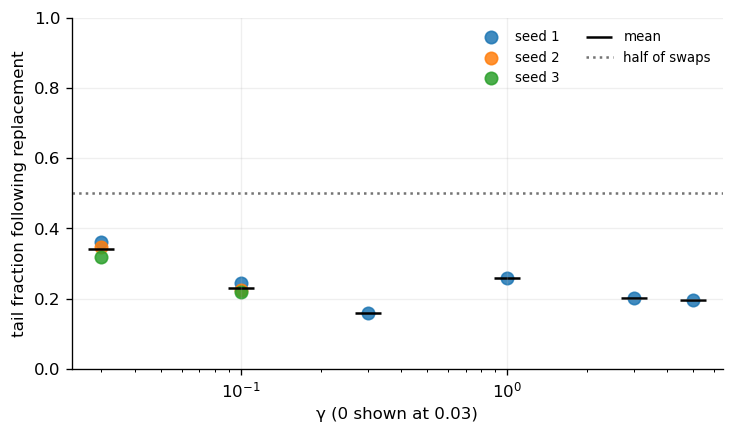

,mean,std,count
gamma,,,
0.0,0.342,0.022,3
0.1,0.229,0.014,3
0.3,0.160,NaN,1
1.0,0.259,NaN,1
3.0,0.202,NaN,1
5.0,0.195,NaN,1


In [8]:
if SW is not None:
    t=(SW[SW.part=="tail"].groupby(["gamma","seed"]).ordering_correct.mean().reset_index())
    display(t.pivot(index="seed",columns="gamma",values="ordering_correct").round(3))
    fig,ax=plt.subplots(figsize=(7,3.8))
    for seed,d in t.groupby("seed"):
        x=[g if g>0 else 0.03 for g in d.gamma]
        ax.scatter(x,d.ordering_correct,s=55,label=f"seed {seed}",alpha=.85)
    means=t.groupby("gamma").ordering_correct.agg(["mean","std","count"])
    x=[g if g>0 else 0.03 for g in means.index]
    ax.scatter(x,means["mean"],marker="_",s=260,color="black",label="mean")
    ax.axhline(.5,color="0.45",ls=":",label="half of swaps")
    ax.set_xscale("log"); ax.set_ylim(0,1); ax.set_xlabel("γ (0 shown at 0.03)")
    ax.set_ylabel("tail fraction following replacement"); ax.legend(ncol=2,fontsize=8)
    ax.grid(alpha=.2); plt.show()
    display(means.round(3))


**Decision rule:** do not call a wiggle a γ trend unless it repeats across seeds. At present,
the supported statement is only that turning minimality on did not rescue tail swap-following.


## 3 · Could visibility explain the MCBM tail result?

Repeat the same test-time visibility control as for CBM. Improving after the filter means
visibility contributes; remaining far below foot means it is incomplete.


,tail_all,tail_visible,foot_visible(grounded)
gamma,,,
0.0,0.342,0.425,0.868
0.1,0.229,0.277,0.944
0.3,0.160,0.216,0.935
1.0,0.259,0.309,0.936
3.0,0.202,0.259,0.966
5.0,0.195,0.240,0.956


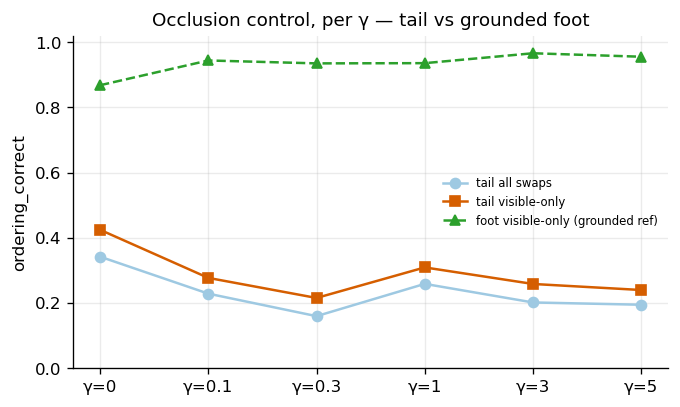

In [9]:
if SW is not None and "pixel_count_cf" in SW.columns:
    allg=SW[SW.part=="tail"].groupby("gamma").ordering_correct.mean()
    visg=SW[(SW.part=="tail")&(SW.pixel_count_cf>=50)].groupby("gamma").ordering_correct.mean()
    footv=SW[(SW.part=="foot")&(SW.pixel_count_cf>=50)].groupby("gamma").ordering_correct.mean()
    D=pd.DataFrame({"tail_all":allg,"tail_visible":visg,"foot_visible(grounded)":footv}); display(D.round(3))
    fig,ax=plt.subplots(figsize=(6.4,3.6)); x=np.arange(len(D))
    ax.plot(x,D["tail_all"],"o-",label="tail all swaps",color="#9ec9e2")
    ax.plot(x,D["tail_visible"],"s-",label="tail visible-only",color=MCBM_C)
    ax.plot(x,D["foot_visible(grounded)"],"^--",label="foot visible-only (grounded ref)",color="#2ca02c")
    ax.set_xticks(x); ax.set_xticklabels([f"γ={g:g}" for g in D.index]); ax.set_ylim(0,1.02)
    ax.set_ylabel("ordering_correct"); ax.legend(fontsize=7); ax.set_title("Occlusion control, per γ — tail vs grounded foot")
else: print("[pending] mcbm swap CSVs with pixel_count_cf")

**Observation:** visible-only filtering improves tail at every γ, so test-time visibility is
part of the story. Tail remains far below the grounded foot control, so it is not the whole
story. This still leaves training-time occlusion unresolved; γ changes latent compression,
not the label/pixel contradiction that may teach species reliance.


## 4 · Does deletion tell the same broad story?

Deletion is a useful second intervention but a weaker one: it creates an absent state and
cannot reveal which replacement variant the model follows. Show parts separately; the overall
average hides the effect.


tail retained_frac by γ (mean±std over seeds):


,gamma,mean,std
3,0.0,0.284,0.080
8,0.1,0.358,0.152
13,0.3,0.420,NaN
18,1.0,0.360,NaN
23,3.0,0.265,NaN
28,5.0,0.450,NaN


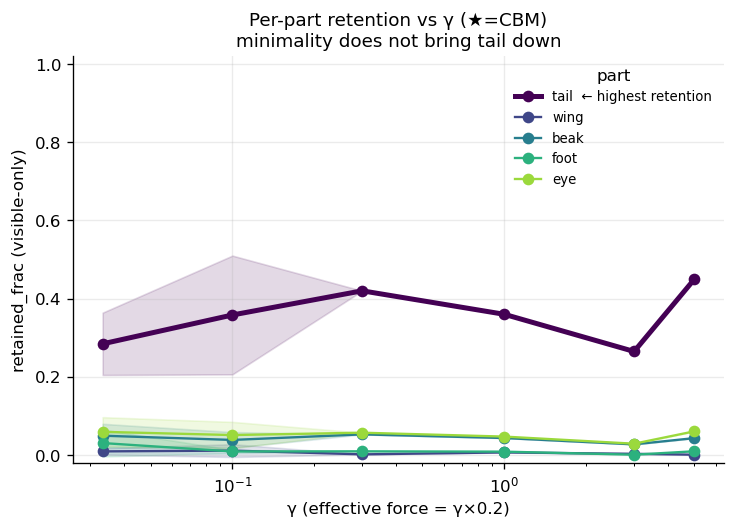

In [10]:
recs=[]
for f in sorted(glob.glob(str(CURATED/"grounding"/"funnybirds-*-s*.parquet"))):
    pr=parse_stem(Path(f).stem)
    if pr is None or pr[0]=="vanilla": continue
    model,gamma,seed=pr; d=pd.read_parquet(f)
    if "changed_frac" in d.columns: d=d[d["changed_frac"]>EPS]
    gg=d.groupby("part").agg(pi=("p_intact","mean"),pr=("p_removed","mean"))
    for part,row in gg.iterrows(): recs.append(dict(model=model,gamma=gamma,seed=seed,part=part,retained_frac=row.pr/row.pi))
P=pd.DataFrame(recs)
if len(P):
    parts=["tail","wing","beak","foot","eye"]
    A=P.groupby(["model","gamma","part"]).retained_frac.agg(["mean","std"]).reset_index()
    mc=A[A.model=="mcbm"]; cbm_pp=A[A.model=="cbm"].set_index("part")["mean"]
    floor=(mc.gamma[mc.gamma>0].min() or 0.05)/3
    fig,ax=plt.subplots(figsize=(7,4.4)); cmap=plt.cm.viridis(np.linspace(0,0.85,len(parts)))
    for part,col in zip(parts,cmap):
        s=mc[mc.part==part].sort_values("gamma");
        if not len(s): continue
        x=s.gamma.replace(0,floor)
        ax.plot(x,s["mean"],"o-",color=col,lw=3 if part=="tail" else 1.4,label=part+("  ← highest retention" if part=="tail" else ""))
        ax.fill_between(x, s["mean"]-s["std"].fillna(0), s["mean"]+s["std"].fillna(0), color=col, alpha=0.15)
        if part in cbm_pp.index: ax.scatter([floor/1.6],[cbm_pp[part]],marker="*",s=90,color=col,zorder=5)
    ax.set_xscale("log"); ax.set_xlabel("γ (effective force = γ×0.2)"); ax.set_ylabel("retained_frac (visible-only)")
    ax.set_ylim(-0.02,1.02); ax.set_title("Per-part retention vs γ (★=CBM)\nminimality does not bring tail down"); ax.legend(title="part",fontsize=8)
    print("tail retained_frac by γ (mean±std over seeds):")
    display(mc[mc.part=="tail"][["gamma","mean","std"]].sort_values("gamma").round(3))
else: print("[pending] bash analysis/grounding_sweep.sh")

Tail again differs from other parts. Because most settings have one seed and γ saturates early,
do not read the connected points as a smooth effect of γ. Deletion supports the existence of a
tail-specific problem but is not the main causal figure.


## 5 · Is species information still available in the concept layer?

Minimality could change `z` without removing the class information available from the full
reported concept vector. A probe shows availability, not which information a specific concept
prediction actually used.


,gamma,c,tail,chance
0,0.0,0.984,0.203,0.02
1,0.1,0.988,0.218,0.02
2,0.3,0.990,0.190,0.02
3,1.0,0.994,0.198,0.02
4,3.0,0.986,0.268,0.02
5,5.0,0.998,0.272,0.02


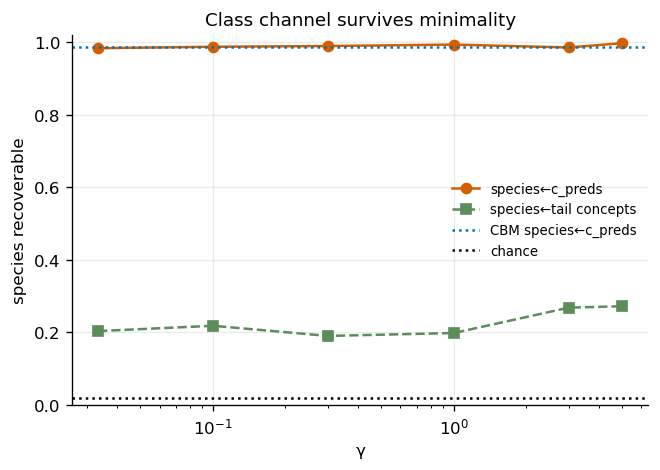

In [11]:
rows=[]
for f in sorted(glob.glob(str(CURATED/"species_probe"/"funnybirds-mcbm-g*-s*.json"))):
    m=re.search(r"-g([0-9p]+)-s(\d+)\.json$", Path(f).name)
    if not m: continue
    S=json.loads(Path(f).read_text())
    rows.append(dict(gamma=float(m.group(1).replace("p",".")), seed=int(m.group(2)),
                     c=S["species_from_cpreds"]["acc"], tail=S["species_from_part_cpreds"].get("tail",{}).get("acc",np.nan),
                     chance=S["chance"]))
if rows:
    D=pd.DataFrame(rows); Dg=D.groupby("gamma").agg(c=("c","mean"),tail=("tail","mean"),chance=("chance","first")).reset_index()
    display(Dg.round(3)); floor=(Dg.gamma[Dg.gamma>0].min() or 0.05)/3
    cbj=sorted(glob.glob(str(CURATED/"species_probe"/"funnybirds-cbm-s*.json")))
    fig,ax=plt.subplots(figsize=(6.2,4))
    ax.plot(Dg.gamma.replace(0,floor),Dg.c,"o-",color=MCBM_C,label="species←c_preds")
    ax.plot(Dg.gamma.replace(0,floor),Dg["tail"],"s--",color="#5B8C5A",label="species←tail concepts")
    if cbj: ax.axhline(np.mean([json.loads(Path(p).read_text())["species_from_cpreds"]["acc"] for p in cbj]),ls=":",color=CBM_C,label="CBM species←c_preds")
    ax.axhline(Dg.chance.iloc[0],ls=":",color="k",label="chance"); ax.set_xscale("log")
    ax.set_xlabel("γ"); ax.set_ylabel("species recoverable"); ax.set_ylim(0,1.02); ax.legend(fontsize=8)
    ax.set_title("Class channel survives minimality")
else: print("[pending] grounding_sweep.sh runs the probe too")

Report the exact γ and seed coverage beside this graph. A single γ point cannot establish a
trend. Near-perfect species recovery from the whole concept vector shows that a class channel
remains available, but it does not alone prove tail backwash.


## 6 · Does the concept failure affect the final prediction?

Use the same downstream check as CBM. The concept explanation can fail even when the species
prediction remains stable.


In [ ]:
if SW is not None and "p_cf_donor" in SW.columns:
    fig,ax=plt.subplots(figsize=(6.8,4.2))
    series=[]
    g0=sorted(SW.gamma.unique())[0]
    series.append((f"MCBM γ={g0:g}",SW[(SW.part=="tail")&(SW.gamma==g0)].copy(),MCBM_C))
    if CB is not None: series.append(("CBM",CB[CB.part=="tail"].copy(),CBM_C))
    summary=[]
    for label,t,col in series:
        if len(t)>8:
            t["mb"]=pd.qcut(t.margin,8,duplicates="drop")
            gb=t.groupby("mb",observed=True).agg(mx=("margin","mean"),my=("p_cf_donor","mean"))
            ax.plot(gb.mx,gb.my,"o-",lw=2,label=label,color=col)
        summary.append({"model":label,"rows":len(t),"mean_P_donor":t.p_cf_donor.mean(),
                        "P_donor_above_.5":(t.p_cf_donor>.5).mean(),"P_donor_above_.9":(t.p_cf_donor>.9).mean()})
    display(pd.DataFrame(summary).set_index("model").round(4))
    ax.axvline(0,color="k",lw=.6); ax.set(xlabel="tail margin (replacement − old)",ylabel="mean P(replacement species)",title="Downstream response: MCBM versus CBM")
    ax.legend(); ax.grid(alpha=.2); plt.show()
    print("P(donor)>.5 is only a proxy for donor dominance; exact class-flip rate requires saving predicted_class in future CSVs.")
else: print("[pending] swap CSV with p_cf_donor")


**Observation:** the average donor-species probability changes only modestly. Keep the claim at
the concept/explanation level; do not imply broad task-accuracy damage.


## 7 · Honest conclusion and the causal next step

The current runs support:
1. γ strongly changes `z`, mostly as an off/on switch by γ=0.1.
2. None of the tested MCBM settings rescues tail swap-following.
3. Wing and foot remain good controls, so the intervention pipeline is not globally broken.
4. Test-time visibility explains part, but not all, of the tail gap.
5. Most γ settings are single-seed and cannot support a smooth trend claim.

This is evidence that MCBM minimality, as exercised here, does not guarantee pixel grounding.
It does not yet uniquely identify why the tail fails. The visibility-aware relabeled model is
the important next experiment: it changes the training labels while holding the swap test and
architecture fixed. That result should decide whether the label/species correlation was a
cause or whether a deeper tail/architecture problem remains.


## Original-notebook provenance

This notebook draws from all 92 cells of
`funnybird_notebooks/fb_mcbm_renderer_swap.ipynb`:

| Current step | Original inspiration | What changed here |
|---|---|---|
| Load and summarize swaps | cells 36–46 and 62–65 | Keeps directions separate; never recreates the misleading 0.50 average |
| Per-swap/part comparison | cells 43–60 | Removes outcome-coloured and arbitrary median-split plots |
| Visibility control | cells 70–76 | Keeps the grounded-foot comparison and separates test-time from training-time occlusion |
| Forward/backward check | cells 66–68 and 79–80 | Uses paired heatmaps; treats symmetry as a bookkeeping check first |
| Compression check | cells 81–84 | Adds the “did γ change z?” guard and exposes γ saturation |
| CBM comparison | cells 85–89 | Keeps CBM separate because γ=0 MCBM is not the same model |
| Relabeling idea | cells 90–91 | Moved to notebook 03rl, where it can be tested by retraining rather than only described |

Original setup/rendering cells 0–35 run in the SLURM driver. The original GT-ceiling panel is
not reproducible with the current minimal-CBM label head and is intentionally omitted rather
than replaced with a misleading number.
